In [1]:
# Instalação necessária no Colab
!pip install osmnx

# Importação das bibliotecas para esta etapa e para os passos futuros
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Configuração opcional para melhorar o uso de cache do OSMnx e log
# ox.config(log_console=True, use_cache=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.0 MB/s eta 0:00:00


In [2]:
# Insira a latitude e longitude do ponto central da sua análise
# -6.0636327,-35.2334585
LATITUDE = -6.0636327
LONGITUDE = -35.2334585
LABEL = "São José de Mipibu - RN"

DISTANCIA_METROS = 4000

In [3]:
centro = (LATITUDE, LONGITUDE)

G = ox.graph.graph_from_point(centro, dist=DISTANCIA_METROS, network_type='drive')
# G = ox.graph.graph_from_place("São José de Mipibu, Rio Grande do Norte, Brazil", network_type='drive')

print(f"Grafo da região '{LABEL}' gerado com sucesso!")

Grafo da região 'São José de Mipibu - RN' gerado com sucesso!


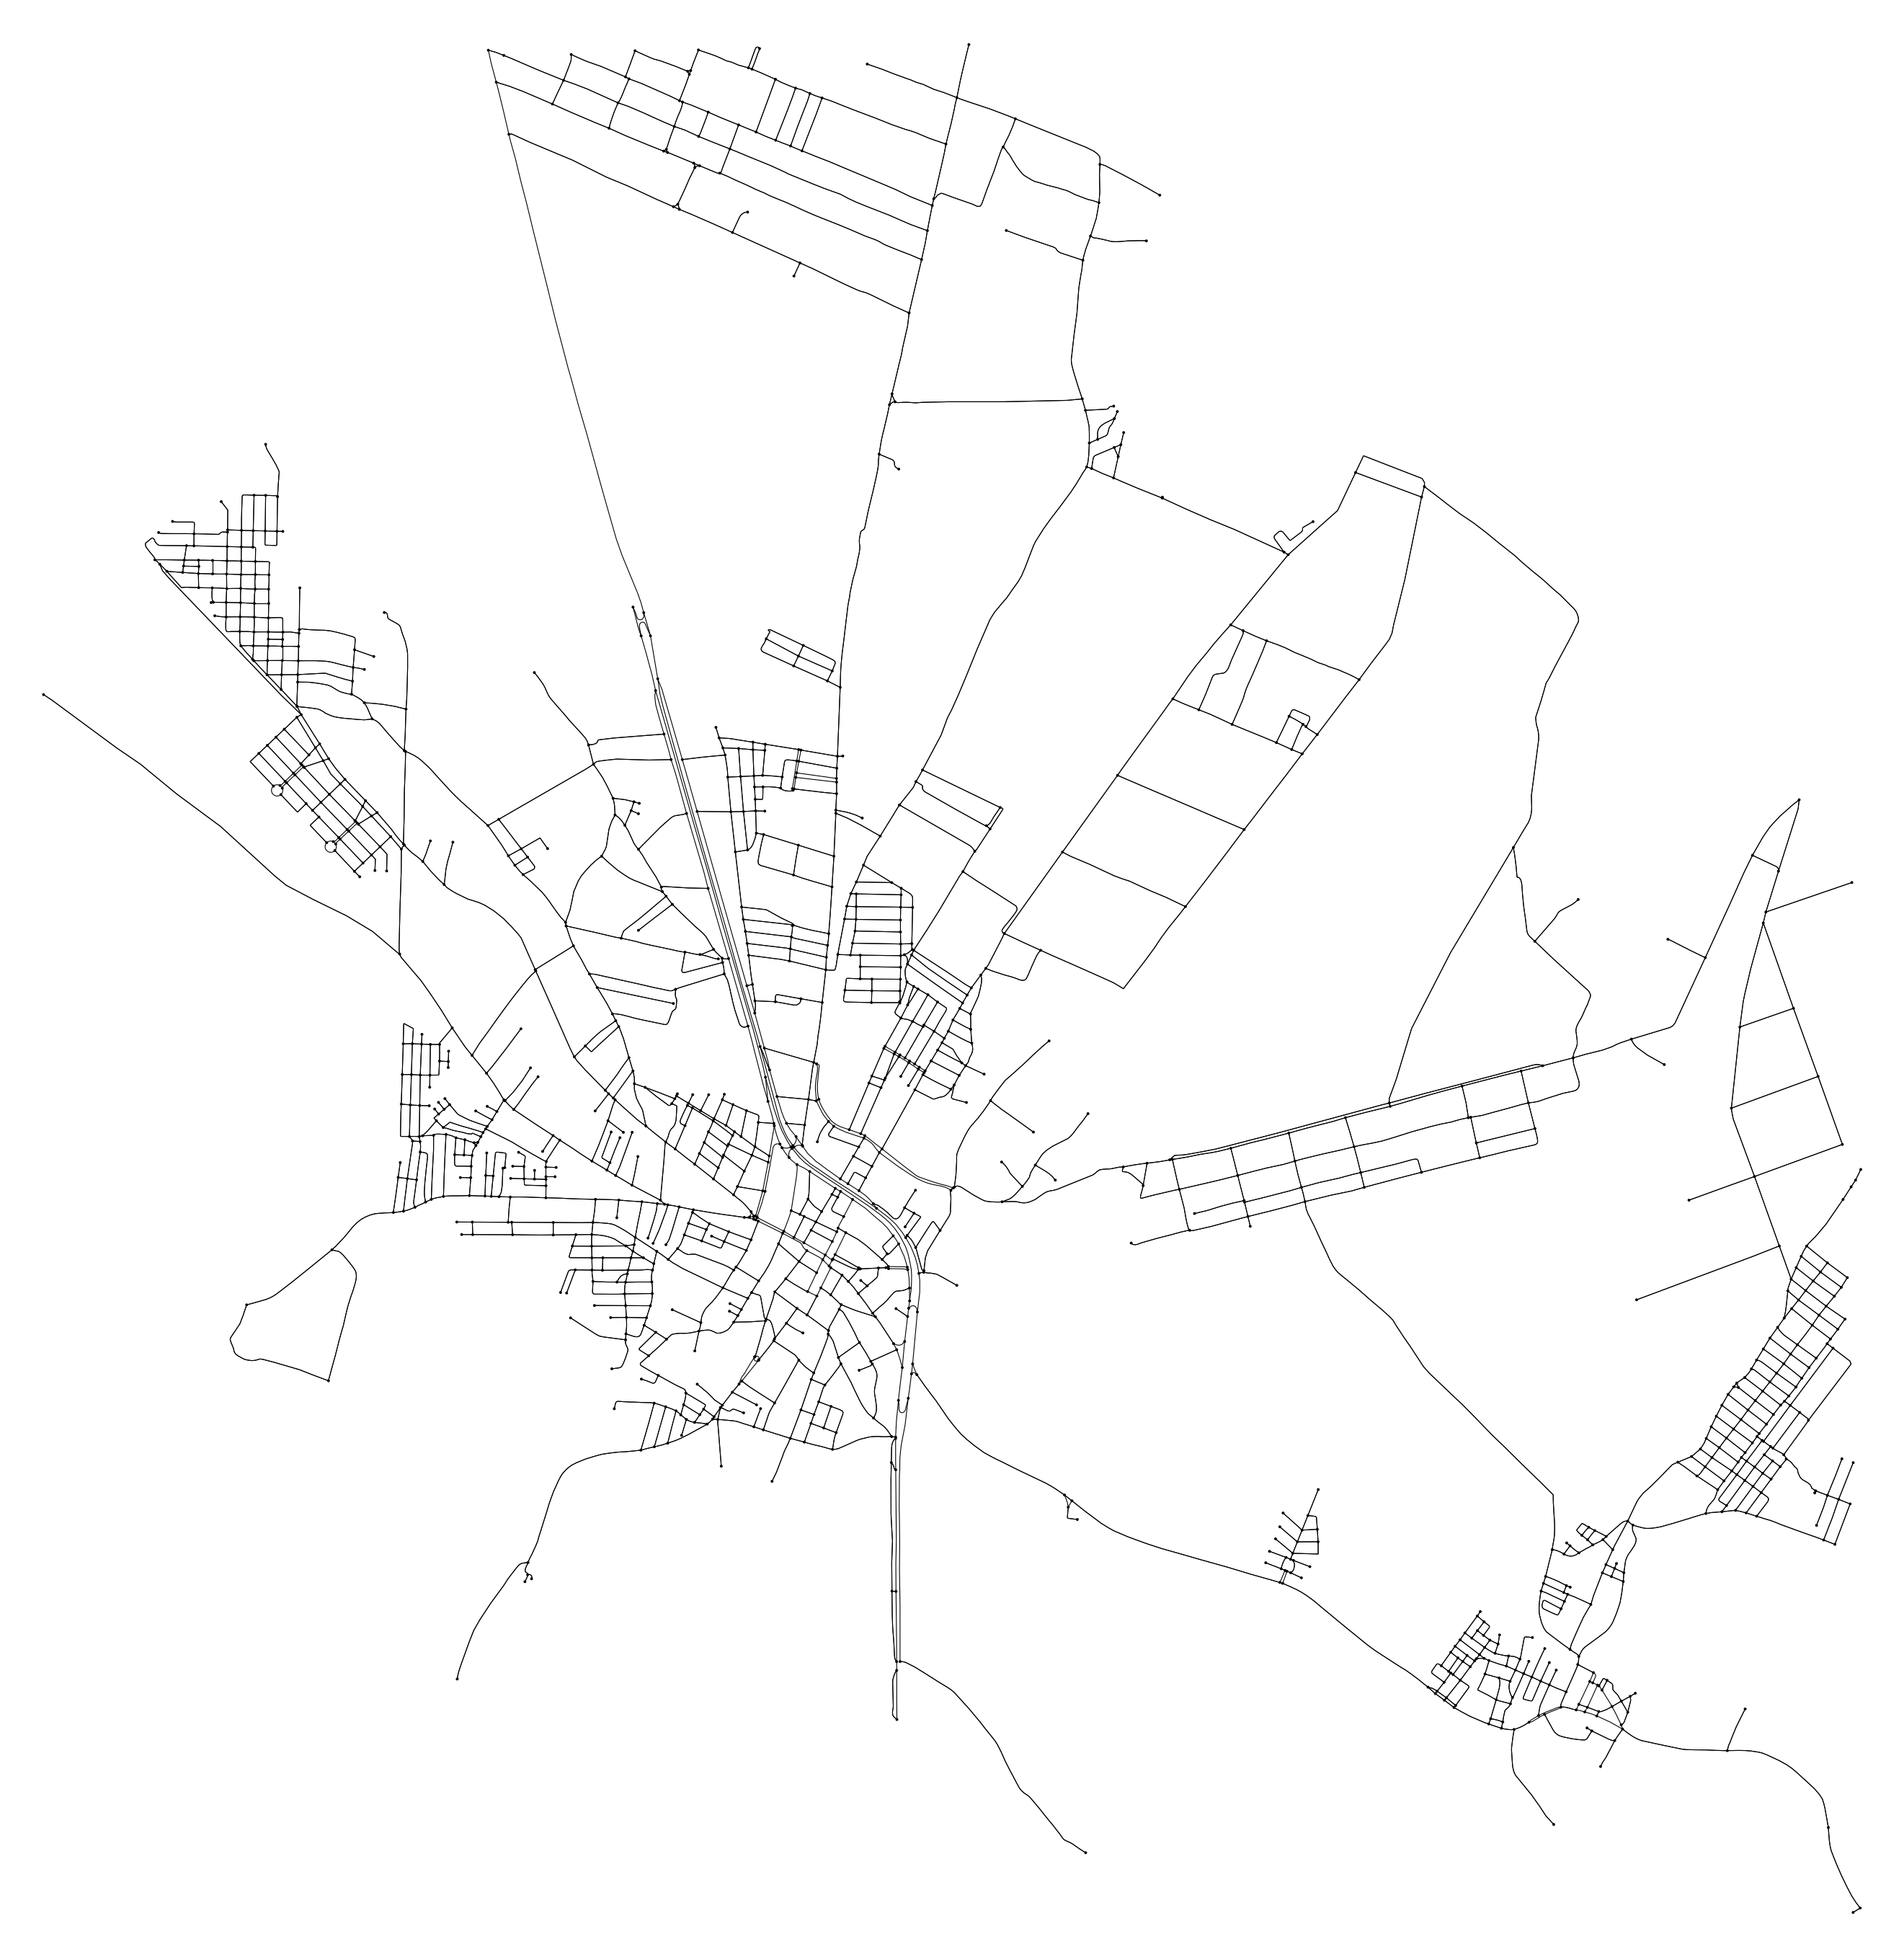

In [4]:
fig, ax = ox.plot.plot_graph(G,
                             figsize=(35, 35),
                             node_size=8,
                             edge_linewidth=0.8,
                             bgcolor='white',
                             node_color='black',
                             edge_color='black'
                             )
# fig, ax = ox.plot_graph(G,
#                         figsize=(..., ...),
#                         node_size=...,
#                         edge_linewidth=1, # espessura da linha
#                         bgcolor='white',  # fundo da imagem
#                         node_color='red', # cor do nó para contraste
#                         edge_color='gray')

In [5]:
# what sized area does our network cover in square meters?
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m
# show some basic stats about the network
ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

{'n': 1343,
 'm': 3679,
 'k_avg': 5.478778853313477,
 'edge_length_total': 429530.13951526675,
 'edge_length_avg': 116.75187265976264,
 'streets_per_node_avg': 2.93596425912137,
 'streets_per_node_counts': {0: 0, 1: 157, 2: 0, 3: 958, 4: 228},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.1169024571854058,
  2: 0.0,
  3: 0.7133283693224125,
  4: 0.16976917349218168},
 'intersection_count': 1186,
 'street_length_total': 228205.31314179927,
 'street_segment_count': 1950,
 'street_length_avg': 117.02836571374321,
 'circuity_avg': 1.033845373366559,
 'self_loop_proportion': 0.0005128205128205128,
 'clean_intersection_count': 927,
 'node_density_km': 29.796069933666562,
 'intersection_density_km': 26.312836143952747,
 'edge_density_km': 9529.642647516339,
 'street_density_km': 5063.009284890043,
 'clean_intersection_density_km': 20.56660970104907}